<a href="https://colab.research.google.com/github/sohitkumar7505/machine_learning_lab/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

In [ ]:
def train_test_split(X, y, test_size=0.2):
    n = len(X)
    indices = np.arange(n)
    np.random.shuffle(indices)

    test_len = int(n * test_size)

    test_idx = indices[:test_len]
    train_idx = indices[test_len:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [ ]:
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # Compute distances
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # Get k nearest indices
        k_indices = np.argsort(distances)[:self.k]

        # Get labels
        k_labels = [self.y_train[i] for i in k_indices]

        # Majority vote
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]

In [ ]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [ ]:
k_sqrt = int(np.sqrt(len(X_train)))
if k_sqrt % 2 == 0:
    k_sqrt += 1   # make it odd

print("K using √n rule:", k_sqrt)

K using √n rule: 11


In [ ]:
model = KNN(k=k_sqrt)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
acc = accuracy(y_test, predictions)

print("Test Accuracy:", acc)

Test Accuracy: 0.9666666666666667


In [ ]:
def cross_validation(X, y, k_values, folds=5):
    fold_size = len(X) // folds
    accuracies = []

    for k in k_values:
        fold_acc = []

        for i in range(folds):
            start = i * fold_size
            end = start + fold_size

            X_val = X[start:end]
            y_val = y[start:end]

            X_train = np.concatenate((X[:start], X[end:]), axis=0)
            y_train = np.concatenate((y[:start], y[end:]), axis=0)

            model = KNN(k=k)
            model.fit(X_train, y_train)

            preds = model.predict(X_val)
            fold_acc.append(accuracy(y_val, preds))

        accuracies.append(np.mean(fold_acc))

    return accuracies

In [ ]:
k_values = list(range(1, 21))
cv_scores = cross_validation(X, y, k_values)

best_k = k_values[np.argmax(cv_scores)]

print("Best K:", best_k)

Best K: 10


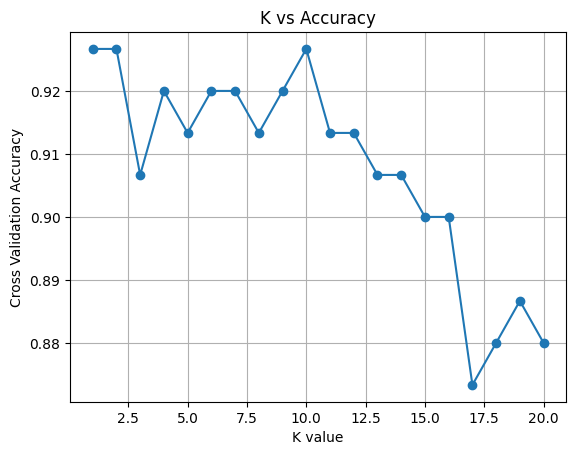

In [ ]:
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("K value")
plt.ylabel("Cross Validation Accuracy")
plt.title("K vs Accuracy")
plt.grid()
plt.show()